In [4]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
import matplotlib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


import hdbscan
import pacmap
from sklearn.cluster import KMeans
from imblearn.under_sampling import CondensedNearestNeighbour  

from sklearn.preprocessing import MinMaxScaler
from scipy import stats

In [6]:
data = pd.read_excel('data/Pyrolysis_Data 6-16_Reduced.xlsx')

data.describe()


,Unnamed: 0,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
count,6669,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,...,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000
mean,2015-12-22 07:16:59.470808576,52086.607262,8712.582010,8287.932362,8842.522833,8603.680748,8444.248226,8865.866092,4297.905730,4452.905547,...,617.811929,622.511101,831.648208,836.780286,835.400132,836.319523,837.300782,837.903612,1027.474983,837.910011
min,2015-11-06 00:00:00,45736.531250,7466.118164,7110.184570,7652.420410,7561.086914,7439.499512,7731.586426,4147.067871,4204.664050,...,603.491333,611.425110,804.398743,809.329590,810.840485,812.086029,811.762329,811.068130,980.803802,813.534363
25%,2015-11-29 03:40:00.007000064,52080.425781,8674.464844,8250.759766,8816.666992,8557.800781,8409.102539,8819.564453,4277.095703,4445.440693,...,614.694580,620.329590,830.853425,836.122177,834.470825,835.493164,836.341479,836.836578,1019.737488,837.743379
50%,2015-12-22 07:19:27.335000064,52136.097656,8731.911133,8286.455078,8849.289062,8605.119141,8459.644902,8884.833008,4288.175293,4462.412109,...,618.976257,622.934143,831.628510,836.826157,835.474991,836.345734,837.407837,838.015167,1029.567841,837.979076
75%,2016-01-14 10:54:36.375000064,52197.140625,8777.038086,8320.266851,8883.692383,8672.966798,8504.736328,8927.785156,4300.790039,4474.368161,...,620.939880,624.776917,832.425751,837.532196,836.445328,837.252701,838.400406,839.075317,1035.154907,838.240967
max,2016-02-06 14:25:05.950000,53489.472656,9053.129883,9278.496829,9080.204688,8854.346362,8805.973330,9129.166016,4469.789062,4630.651488,...,625.199951,629.285583,846.023840,865.560687,845.728282,843.780106,846.446014,850.595634,1045.856140,841.106018
std,NaN,464.738337,121.623591,120.638306,95.786130,107.469695,112.196548,106.172983,40.376338,42.363111,...,3.940449,2.917192,1.910854,2.236806,1.922875,1.811575,2.094034,2.244648,10.038618,1.285605


In [7]:
print(min(np.asarray([i.timestamp() for i in data.iloc[:, 0]])))
print(np.mean(np.asarray([i.timestamp() for i in data.iloc[:, 0]])))
print(max(np.asarray([i.timestamp() for i in data.iloc[:, 0]])))

1446768000.0
1450768619.4708083
1454768705.95


In [9]:

def plot_data(X, y, x_name, y_name, time = None, k = None):

    fig = plt.figure(figsize=(6, 5))
    axs0 = fig.add_subplot(1, 1, 1)

    #for col in data.iloc[:, 1:].columns:
    if time is not None:
        norm = TwoSlopeNorm(vmin=min(time), vcenter=np.mean(time), vmax=max(time))
        colors = [plt.cm.jet(norm(c)) for c in time]

    axs0.scatter(X, y, color = 'none', marker = 'o', edgecolors=colors, linewidth=1)

    if k is None:
        axs0.text(9000, 8000, s = 'All data', fontsize='x-large')
    else:
        axs0.text(9000, 8000, s = f'k = {k}', fontsize='x-large')

    axs0.set_xlabel(f'{x_name}', labelpad = 10, fontsize='x-large')
    axs0.set_ylabel(f'{y_name}', labelpad = 10, fontsize='x-large')

    axs0.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large', 
                        #rotation=45
                        )

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs0.spines[ax].set_linewidth(1)

    cbaxes = inset_axes(axs0, width="30%", height="3%", loc='upper right')

    cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cm.jet), cax=cbaxes, shrink = 0.7, aspect = 30, orientation = 'horizontal')#, pad = 1)
    #plt.colorbar(cax=cbaxes, ticks=[0.,1], orientation='horizontal')

    
    cb.outline.set_linewidth(0.1)
    cb.ax.set_xlabel(r'$ \rm Time$', fontsize = 'x-large')
    cb.ax.tick_params(size=0)
    cb.set_ticks([])

    axs0.set_xlim(7250, 9500)
    axs0.set_ylim(7700, 9500)

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return None

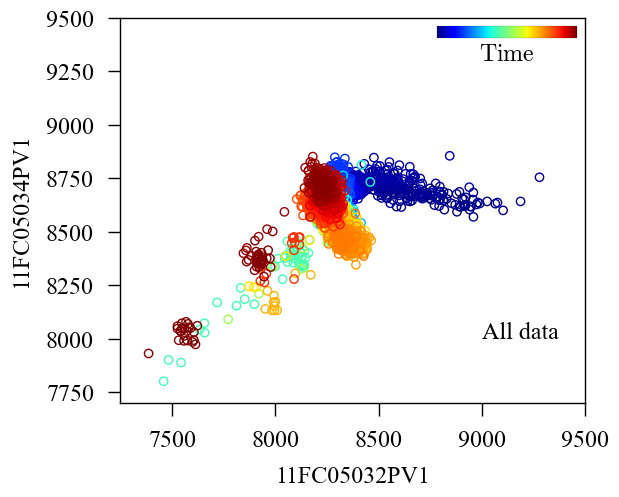

In [11]:
X = "11FC05032PV1"
y = "11FC05034PV1"

plot_data(data.iloc[:, data.columns.get_loc(X)], data.iloc[:, data.columns.get_loc(y)], X, y, time = np.asarray([i.timestamp() for i in data.iloc[:, 0]]))

In [12]:
def get_clusters(data, basis_data = None, dr_model = None):
    scaler = MinMaxScaler(feature_range=(-1, 1))

    try:
        
        scaled_data = pd.DataFrame(scaler.fit_transform(data.iloc[:, 0:]))

    except:
        scaled_data = pd.DataFrame(scaler.fit_transform(data.iloc[:, 1:]))

    print(scaled_data.head())

    reduced_data = scaled_data

    # get clusters

    cl_model = hdbscan.HDBSCAN(min_cluster_size=5)    

    labels = cl_model.fit_predict(reduced_data)

    data['labels'] = labels


    return data, dr_model, data.labels

In [13]:
data_reduced = pd.DataFrame()
data_reduced[X] = data.iloc[:, data.columns.get_loc(X)]
data_reduced[y] = data.iloc[:, data.columns.get_loc(y)]

data_clustered, dr_model, labels = get_clusters(data_reduced)

data_clustered.head()

          0         1
0  0.295393  0.765424
1  0.334001  0.748758
2  0.705238  0.558626
3  0.517917  0.682384
4  0.687721  0.611121


/Users/lbrice1/venvs/aicheme/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/lbrice1/venvs/aicheme/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,11FC05032PV1,11FC05034PV1,labels
0,8514.593137,8702.662279,11
1,8556.450386,8691.885549,12
2,8958.929290,8568.940794,-1
3,8755.843789,8648.966226,-1
4,8939.937799,8602.885921,5


In [15]:
k = 5

cnn = CondensedNearestNeighbour(random_state=42, n_neighbors=k, sampling_strategy='auto')

data_sampled_cnn = cnn.fit_resample(data_clustered, data_clustered['labels'])[0]


data_sampled_cnn['post_index'] = cnn.sample_indices_

data_sampled_cnn = data_sampled_cnn.drop_duplicates()

data_sampled_cnn['time'] = data.iloc[data_sampled_cnn['post_index'], 0]

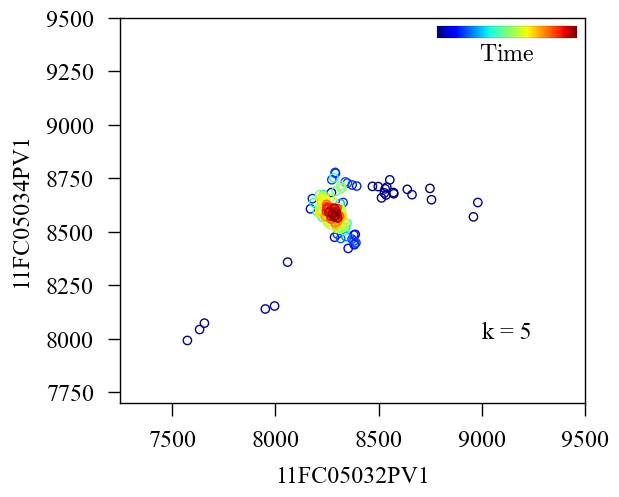

In [17]:
X = "11FC05032PV1"
y = "11FC05034PV1"

data_sampled_cnn = data_sampled_cnn.dropna()

plot_data(data_sampled_cnn.iloc[:, data_sampled_cnn.columns.get_loc(X)], data_sampled_cnn.iloc[:, data_sampled_cnn.columns.get_loc(y)], X, y, time = np.asarray([i.timestamp() for i in data_sampled_cnn['time']]), k = k)